In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
df=gpd.read_file('C:/Users/LOQ/Desktop/CHICAGO WALMART/Competitors data.geojson')
df.head()

,id,@id,addr:city,addr:country,addr:housenumber,addr:postcode,addr:state,addr:street,addr:street:name,addr:street:prefix,...,ref:walmart,sensory_friendly:accommodation,sensory_friendly:conditional,shop,short_name,source,start_date,website,@geometry,geometry
0,way/209619049,way/209619049,Chicago,None,9400,60620,IL,South Ashland Avenue,95th,West,...,None,None,None,supermarket,None,None,None,https://local.jewelosco.com/il/chicago/9400-s-...,center,POINT (-87.66346 41.72303)
1,way/209633443,way/209633443,Chicago,None,1841,60620,IL,West 79th Street,79th,West,...,None,None,None,supermarket,None,None,None,None,center,POINT (-87.66984 41.75002)
2,way/209637974,way/209637974,Chicago,None,7907-7911,60620,IL,South Wood Street,Wood,South,...,None,None,None,supermarket,None,None,None,None,center,POINT (-87.66801 41.75004)
3,way/209656270,way/209656270,Chicago,None,7030,60636,IL,South Ashland Avenue,Ashland,South,...,None,None,None,supermarket,None,None,None,https://www.food4less.com/stores/details/708/0...,center,POINT (-87.66448 41.76546)
4,way/210031818,way/210031818,Chicago,None,10700,60628,IL,South Halsted Street,Halsted,South,...,None,None,None,supermarket,None,None,None,https://savealot.com/grocery-stores/chicago-60...,center,POINT (-87.64296 41.69864)


In [3]:
df.geometry.head()

0    POINT (-87.66346 41.72303)
1    POINT (-87.66984 41.75002)
2    POINT (-87.66801 41.75004)
3    POINT (-87.66448 41.76546)
4    POINT (-87.64296 41.69864)
Name: geometry, dtype: geometry

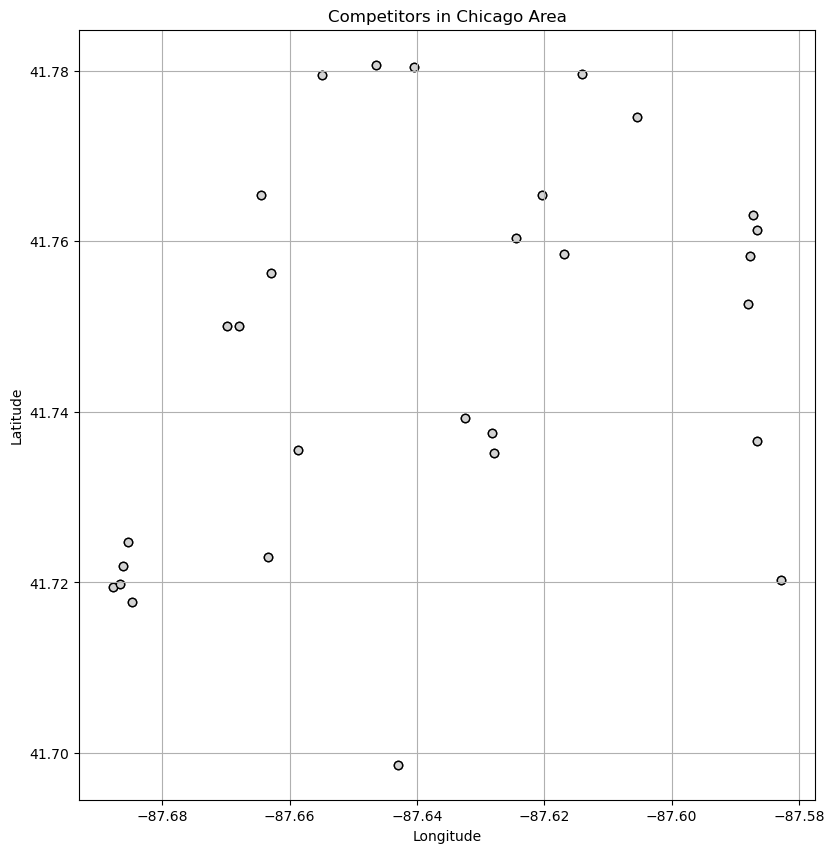

In [4]:
fig,ax=plt.subplots(figsize=(10,10))
df.plot(ax=ax, color='lightgrey', edgecolor='black')
df.plot(ax=ax, color='lightgrey', edgecolor='black'
)
plt.title('Competitors in Chicago Area')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

In [5]:
from shapely.geometry import Point
import geopandas as gpd

walmart = gpd.GeoDataFrame(
    {'name':['Walmart Chatham']},
    geometry=[Point(-87.6616,41.7578)],
    crs=df.crs
)

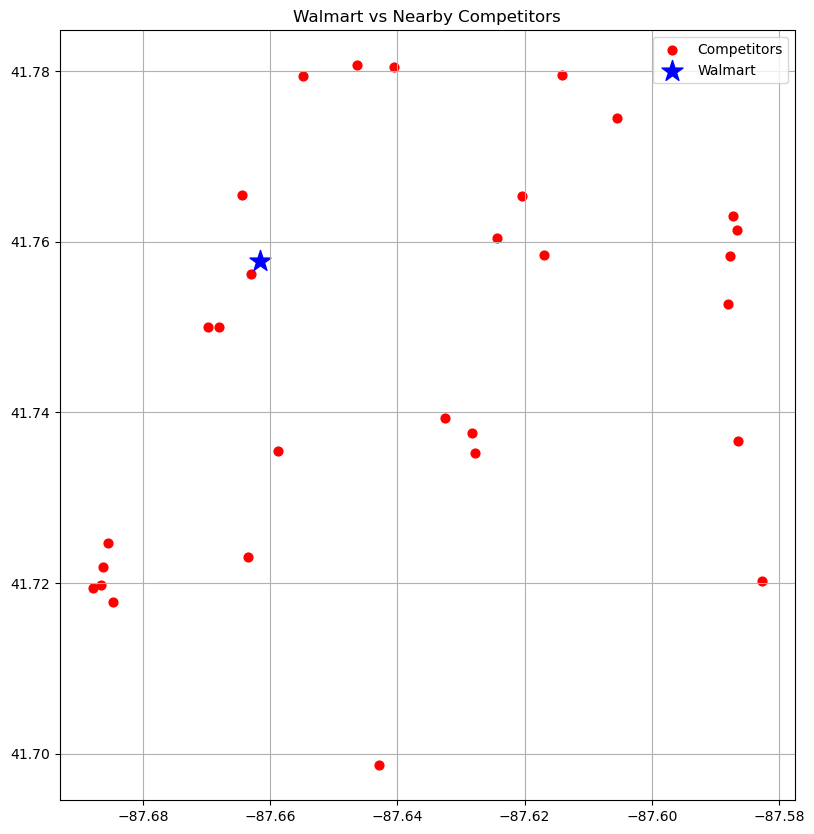

In [6]:
fig, ax = plt.subplots(figsize=(10,10))

df.plot(
    ax=ax,
    color='red',
    markersize=40,
    label='Competitors'
)

walmart.plot(
    ax=ax,
    color='blue',
    marker='*',
    markersize=250,
    label='Walmart'
)

plt.legend()
plt.title("Walmart vs Nearby Competitors")
plt.grid(True)

plt.show()

In [7]:
# Remove Walmart stores
df = df[~df["brand"].str.contains("Walmart", case=False, na=False)].copy()

# Create projected copies (meters)
df_proj = df.to_crs(epsg=26971)
walmart_proj = walmart.to_crs(epsg=26971)

# Calculate distances in meters
df_proj["distance_m"] = df_proj.geometry.distance(walmart_proj.geometry.iloc[0])

# Convert to km
df_proj["distance_km"] = df_proj["distance_m"] / 1000

# Copy distances back
df["distance_km"] = df_proj["distance_km"].values

# Nearest competitor
nearest = df.loc[df["distance_km"].idxmin()]

print(nearest[["name","brand","distance_km"]])

print("\nWithin 1 km :", (df["distance_km"] <= 1).sum())
print("Within 2 km :", (df["distance_km"] <= 2).sum())
print("Within 3 km :", (df["distance_km"] <= 3).sum())
print("Within 5 km :", (df["distance_km"] <= 5).sum())

name           Food 4 Less
brand          Food 4 Less
distance_km       0.884116
Name: 3, dtype: object

Within 1 km : 1
Within 2 km : 3
Within 3 km : 6
Within 5 km : 19


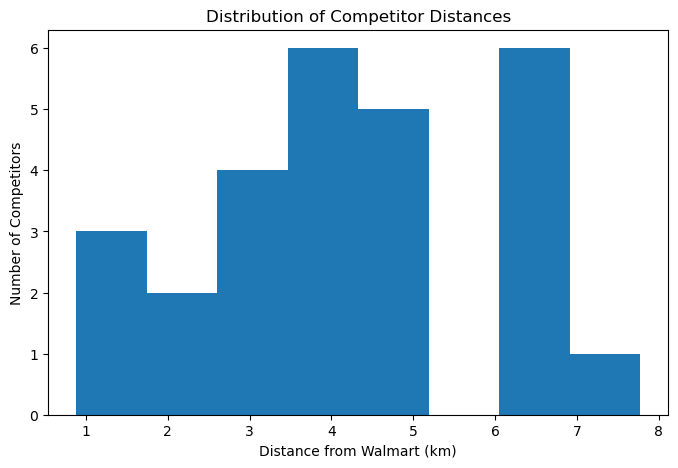

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["distance_km"], bins=8)

plt.xlabel("Distance from Walmart (km)")
plt.ylabel("Number of Competitors")
plt.title("Distribution of Competitor Distances")
plt.show()

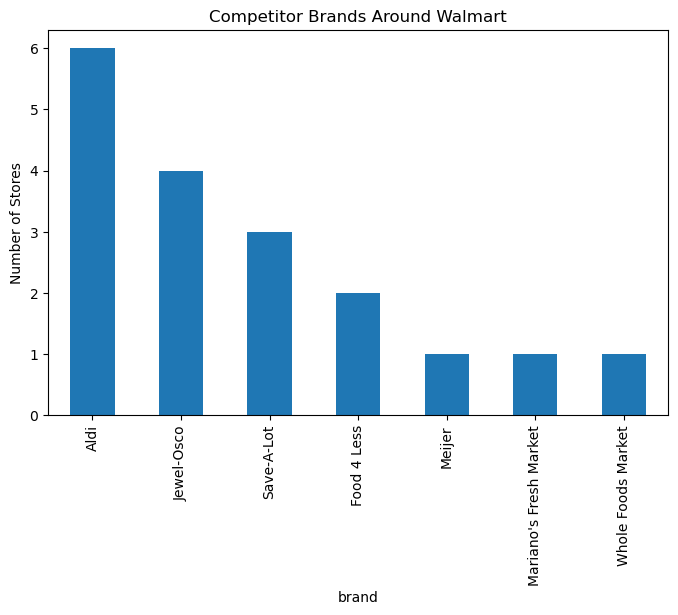

In [9]:
brand_counts = df["brand"].value_counts()

plt.figure(figsize=(8,5))
brand_counts.plot(kind="bar")

plt.title("Competitor Brands Around Walmart")
plt.ylabel("Number of Stores")
plt.show()

In [10]:
import folium 
m=folium.Map( location=[41.7578, -87.6616],zoom_start=12)

folium.Marker(
    [41.7578, -87.6616],
    popup="Closed Walmart (Chatham)",
    tooltip="Walmart",
    icon=folium.Icon(color="blue", icon="shopping-cart", prefix="fa")
).add_to(m)

for _, row in df.iterrows():

    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=f"""
        <b>{row['name']}</b><br>
        Brand: {row['brand']}<br>
        Distance: {row['distance_km']:.2f} km
        """,
        tooltip=row["name"],
        icon=folium.Icon(color="red")
    ).add_to(m)

folium.Circle(
    location=[41.7578, -87.6616],
    radius=1000,
    color="green",
    fill=False
).add_to(m)

folium.Circle(
    location=[41.7578, -87.6616],
    radius=3000,
    color="orange",
    fill=False
).add_to(m)

folium.Circle(
    location=[41.7578, -87.6616],
    radius=5000,
    color="red",
    fill=False
).add_to(m)

display(m)
m.save("walmart_competitors_map.html")

In [ ]:
df.to_csv("competitors_with_distances.csv", index=False)

: 

In [1]:
import pandas as pd
import re

df = pd.read_csv("competitors_with_distances.csv")

def extract_coords(point):
    match = re.match(r"POINT \(([-0-9.]+) ([-0-9.]+)\)", point)
    if match:
        lon = float(match.group(1))
        lat = float(match.group(2))
        return pd.Series([lat, lon])
    return pd.Series([None, None])

df[["latitude", "longitude"]] = df["geometry"].apply(extract_coords)

df.to_csv("competitors_powerbi.csv", index=False)